# Step 2: The MNIST dataset

## Loading the images

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print("🔄 Downloading the MNIST dataset... (this might take a few seconds)")
# Fetch MNIST dataset directly from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# X contains the images, y contains the correct answers (the digits 0-9)
X, y = mnist.data, mnist.target

print("✅ Download complete!\n")

🔄 Downloading the MNIST dataset... (this might take a few seconds)
✅ Download complete!



In [ ]:
# ==========================================
# 1. WHAT IS THE DATASET MADE OF?
# ==========================================
print("--- 1. DATASET BASICS ---")
print(f"Total number of images: {X.shape[0]}")
print(f"Size of each image array: {X.shape[1]} pixels (which is a 28 x 28 grid)")
print(f"Labels type: {type(y[0])} (e.g., '{y[0]}')")

# Convert labels from strings to integers
y = y.astype(int)

--- 1. DATASET BASICS ---
Total number of images: 70000
Size of each image array: 784 pixels (which is a 28 x 28 grid)
Labels type: <class 'numpy.int64'> (e.g., '5')


In [ ]:
# ==========================================
# 2. HOW IS A SINGLE IMAGE STORED?
# ==========================================
print("\n--- 2. HOW COMPUTERS SEE IMAGES ---")
# Pick the very first image
first_image_flat = X[0]
first_label = y[0]

print(f"The first image is a handwritten: {first_label}")
print("\nRaw pixel numbers (0 = pure white background, 255 = dark ink):")

# Reshape the 784 numbers into a 28x28 2D grid
first_image_grid = first_image_flat.reshape(28, 28)

# Print a simplified "text picture" using pixel numbers
for row in first_image_grid:  # Sample every 2nd row/col so it fits on screen
    line = "".join([f"{int(pixel):3d} " if pixel > 50 else "  . " for pixel in row])
    print(line)


--- 2. HOW COMPUTERS SEE IMAGES ---
The first image is a handwritten: 5

Raw pixel numbers (0 = pure white background, 255 = dark ink):
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 126 136 175   . 166 255 247 127   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .  94 154 170 253 253 253 253 253 225 172 253 242 195  64   .   .   .   . 
  .   .   .   .   .   .   .   . 238 253 253 253 253 253 253 253 253 251 

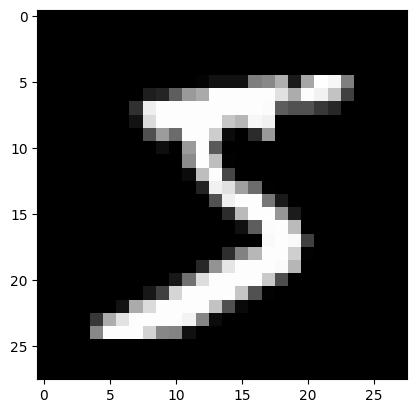

In [ ]:
plt.imshow(first_image_grid, cmap='gray')


--- 3. VISUALIZING DIGITS ---


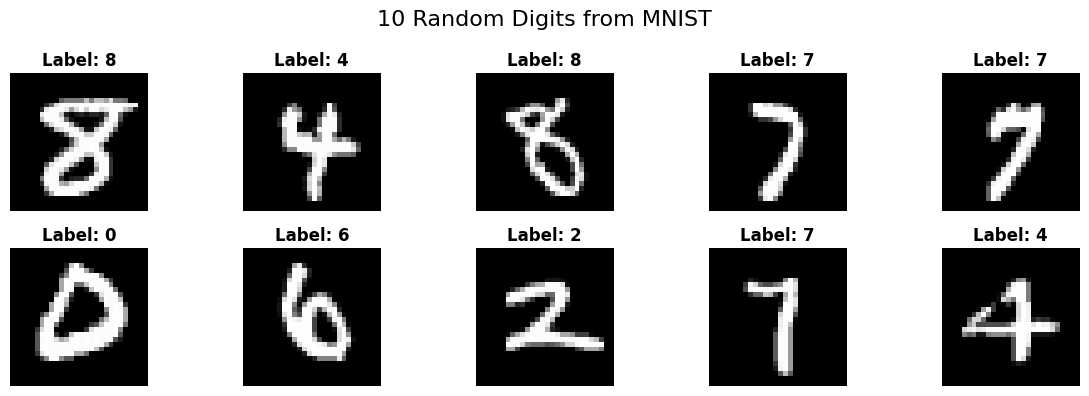

In [ ]:
# ==========================================
# 3. LET'S PLOT SOME IMAGES!
# ==========================================
print("\n--- 3. VISUALIZING DIGITS ---")

# Plot 1: Look at 10 random images in a row
plt.figure(figsize=(12, 4))
np.random.seed(42)  # For reproducible random picks
random_indices = np.random.choice(len(X), 10, replace=False)

for index, idx in enumerate(random_indices):
    plt.subplot(2, 5, index + 1)
    # Reshape from 784 1D array to 28x28 2D image matrix
    image_matrix = X[idx].reshape(28, 28)

    # Display in grayscale (black background, white drawing)
    plt.imshow(image_matrix, cmap='gray')
    plt.title(f"Label: {y[idx]}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle("10 Random Digits from MNIST", fontsize=16)
plt.tight_layout()
plt.show()


--- 4. THE 'AVERAGE' NUMBER 3 ---


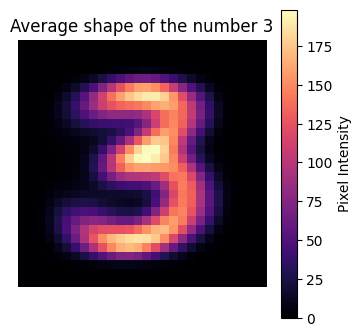

In [ ]:
# ==========================================
# 4. FUN EXPERIMENT: AVERAGE DIGIT
# ==========================================
# What does the "average" drawing of a number look like?
print("\n--- 4. THE 'AVERAGE' NUMBER 3 ---")

# Find all indices where the digit is '3'
threes_indices = np.where(y == 3)[0]
threes_images = X[threes_indices]

# Calculate the average pixel values across all '3's
average_three = np.mean(threes_images, axis=0).reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(average_three, cmap='magma')  # Fun color map!
plt.title("Average shape of the number 3", fontsize=12)
plt.colorbar(label="Pixel Intensity")
plt.axis('off')
plt.show()

## Training a perceptron model on the MNIST dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

NOTE: THERE ARE TEN CLASSES AND NOT TWO, ITS NOT BINARY CLASSIFICATION. YOU THEREFORE NEED TO TRAIN MULTIPLE BINARY MODELS TO CLASSIFY THESE TEN CLASSES.

The options are:

- One against all.
- Pirwise.

FOR SIMPLICITY, LETS JUST BUILD A MODEL TO CLASSIFY BETWEEN TWO OF THE DIGITS, OF YOUR BICK.

Your implementation here: